## Figure 3B & S4D

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import esm
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from collections import OrderedDict
from torch.utils.data import DataLoader, Dataset
from esm.modules import TransformerLayer, ESM1bLayerNorm

class IndexedUniRef(Dataset):
    def __init__(self, fasta_file, index_file, target_len):
        self.target_len = target_len
        self.fasta_file = fasta_file
        with open(index_file, 'rb') as f:
            self.index = pkl.load(f)
        self.f = None

    def _open_file_if_needed(self):
        if self.f is None: self.f = open(self.fasta_file, 'r')

    def _read_sequence_at_offset(self, offset):
        self._open_file_if_needed()
        self.f.seek(offset)
        header_line = self.f.readline().strip()
        if not header_line.startswith(">"): return "ERROR_ID", "X"
        seq_id = header_line[1:].split()[0].strip()
        seq_parts = []
        while True:
            line = self.f.readline()
            if not line or line.startswith('>'): break
            seq_parts.append(line.strip())
        full_seq = "".join(seq_parts)
        processed_seq = full_seq.replace('j', 'i').replace('J', 'I')
        return seq_id, processed_seq

    def __len__(self): return len(self.index)

    def __getitem__(self, idx):
        offset = self.index[idx]
        try: seq_id, original_seq = self._read_sequence_at_offset(offset)
        except Exception: seq_id, original_seq = "ERROR_ID", "X"
        original_len = len(original_seq)
        is_complete_start = False; is_complete_end = False; processed_seq = ""
        if original_len > self.target_len:
            start_index = random.randint(0, original_len - self.target_len)
            processed_seq = original_seq[start_index : start_index + self.target_len]
            if start_index == 0: is_complete_start = True
            if (start_index + self.target_len) == original_len: is_complete_end = True
        else:
            max_start_percent = int(original_len * 0.1); max_start_abs = 30
            max_start_index = max(0, min(max_start_percent, max_start_abs))
            max_start_index = min(max_start_index, original_len - 1); max_start_index = max(0, max_start_index)
            start_index = random.randint(0, max_start_index) if max_start_index > 0 else 0
            if start_index == 0: is_complete_start = True
            processed_seq = original_seq[start_index:]; is_complete_end = True
        return seq_id, processed_seq, is_complete_start, is_complete_end

class SequenceCollateFunction:
    def __init__(self, alphabet, model_target_len):
        self.alphabet = alphabet
        self.model_target_len = model_target_len
    def __call__(self, batch):
        all_token_ids = []
        valid_batch = [item for item in batch if item[0] != "ERROR_ID"]
        for (seq_id, seq_str, is_start, is_end) in valid_batch:
            final_seq_parts = []
            if is_start: final_seq_parts.append('<cls>')
            final_seq_parts.append(seq_str)
            if is_end: final_seq_parts.append('<eos>')
            final_seq_str = "".join(final_seq_parts)
            token_ids = list(self.alphabet.encode(final_seq_str))
            if len(token_ids) < self.model_target_len:
                padding = [self.alphabet.padding_idx] * (self.model_target_len - len(token_ids))
                token_ids.extend(padding)
            elif len(token_ids) > self.model_target_len: token_ids = token_ids[:self.model_target_len]
            all_token_ids.append(torch.tensor(token_ids, dtype=torch.long))
        if not all_token_ids:
             dummy = torch.full((1, self.model_target_len), self.alphabet.padding_idx, dtype=torch.long)
             return dummy, dummy
        batch_tokens = torch.stack(all_token_ids, dim=0)
        batch_targets = batch_tokens.clone()
        batch_targets[batch_tokens == self.alphabet.padding_idx] = -100
        return batch_tokens, batch_targets

class LayerNorm1d(nn.Module):
    def __init__(self, num_channels, eps=1e-5):
        super().__init__()
        self.norm = nn.LayerNorm(num_channels, eps=eps)
    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.norm(x)
        return x.transpose(1, 2)

class ConvUnetAttentionLayer(nn.Module):
    def __init__(self, embed_dim, ffn_embed_dim, attention_heads, dropout=0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.pre_norm = ESM1bLayerNorm(embed_dim)
        self.activation = nn.GELU()
        self.conv1 = nn.Conv1d(embed_dim, embed_dim, kernel_size=5, padding=2)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.pool1 = nn.MaxPool1d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv1d(embed_dim, embed_dim, kernel_size=7, padding=3)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.pool2 = nn.MaxPool1d(kernel_size=2, stride=2)
        self.bottleneck_transformer = TransformerLayer(
            embed_dim=embed_dim, ffn_embed_dim=ffn_embed_dim, attention_heads=attention_heads,
            add_bias_kv=False, use_esm1b_layer_norm=True, use_rotary_embeddings=True,
        )
        self.unpool1 = nn.ConvTranspose1d(embed_dim, embed_dim, kernel_size=2, stride=2)
        self.tconv1 = nn.ConvTranspose1d(embed_dim, embed_dim, kernel_size=7, padding=3)
        self.norm_t1 = nn.LayerNorm(embed_dim)
        self.unpool2 = nn.ConvTranspose1d(embed_dim, embed_dim, kernel_size=2, stride=2)
        self.tconv2 = nn.ConvTranspose1d(embed_dim, embed_dim, kernel_size=5, padding=2)
        self.norm_t2 = nn.LayerNorm(embed_dim)
        self.dropout_layer = nn.Dropout(dropout)

    def _apply_norm(self, norm_layer, x_conv):
        x_permuted = x_conv.permute(0, 2, 1)
        x_normed = norm_layer(x_permuted)
        return x_normed.permute(0, 2, 1)

    def forward(self, x, self_attn_padding_mask=None, need_head_weights=False, return_bottleneck_only=False):
        x_residual = x
        x_conv = self.pre_norm(x).permute(1, 2, 0)
        h_conv1 = self.conv1(x_conv)
        skip1 = self.activation(self._apply_norm(self.norm1, h_conv1))
        h_pool1 = self.pool1(skip1)
        h_conv2 = self.conv2(h_pool1)
        skip2 = self.activation(self._apply_norm(self.norm2, h_conv2))
        h_pool2 = self.pool2(skip2)
        h_attn_in = h_pool2.permute(2, 0, 1)
        pooled_padding_mask = None
        if self_attn_padding_mask is not None:
            m = self_attn_padding_mask.float().unsqueeze(1)
            pooled_mask_1 = F.max_pool1d(m, kernel_size=2, stride=2)
            pooled_mask_2 = F.max_pool1d(pooled_mask_1, kernel_size=2, stride=2).bool()
            pooled_padding_mask = pooled_mask_2.squeeze(1)
        attn_out, attn_weights = self.bottleneck_transformer(
            h_attn_in, self_attn_padding_mask=pooled_padding_mask, need_head_weights=need_head_weights,
        )
        if return_bottleneck_only: return attn_out.permute(1, 2, 0)
        h_upsample_in = attn_out.permute(1, 2, 0)
        h_up1 = self.unpool1(h_upsample_in)
        h_up1_tconv = self.tconv1(h_up1 + skip2)
        h_up1 = self.activation(self._apply_norm(self.norm_t1, h_up1_tconv))
        h_up2 = self.unpool2(h_up1)
        h_up2_tconv = self.tconv2(h_up2 + skip1)
        h_up2 = self.activation(self._apply_norm(self.norm_t2, h_up2_tconv))
        x_out = h_up2.permute(2, 0, 1)
        if x_out.shape[0] != x_residual.shape[0]:
            diff = x_residual.shape[0] - x_out.shape[0]
            if diff > 0: x_out = F.pad(x_out, (0,0,0,0,0,diff))
            else: x_out = x_out[:x_residual.shape[0]]
        x = x_residual + self.dropout_layer(x_out)
        return x, attn_weights

class ESM2_ConvUnet_Encoder(nn.Module):
    def __init__(self, num_layers=12, embed_dim=560, attention_heads=20, alphabet="ESM-1b"):
        super().__init__()
        self.num_layers = num_layers
        self.embed_dim = embed_dim
        if not isinstance(alphabet, esm.data.Alphabet): alphabet = esm.data.Alphabet.from_architecture(alphabet)
        self.pad_idx = alphabet.padding_idx
        self.embed = nn.Embedding(len(alphabet), embed_dim, padding_idx=self.pad_idx)
        self.blocks = nn.ModuleList([ConvUnetAttentionLayer(embed_dim, 4*embed_dim, attention_heads) for _ in range(num_layers)])
        self.emb_layer_norm_after = ESM1bLayerNorm(embed_dim)

    def forward_phase2(self, tokens):
        mask = tokens.eq(self.pad_idx)
        x = self.embed(tokens)
        if mask is not None: x = x * (1 - mask.unsqueeze(-1).type_as(x))
        x = x.transpose(0, 1)
        if not mask.any(): mask = None
        for i, layer in enumerate(self.blocks):
            if i == len(self.blocks) - 1: return layer(x, mask, return_bottleneck_only=True)
            else:
                output = layer(x, mask, return_bottleneck_only=False)
                if isinstance(output, tuple): x = output[0]
                else: x = output
        return x

class TransformerAdapter(nn.Module):
    def __init__(self, input_dim, output_dim, num_heads=12, num_layers=4):
        super().__init__()
        self.pre_proj = nn.Linear(input_dim, output_dim)
        self.layers = nn.ModuleList([
            TransformerLayer(embed_dim=output_dim, ffn_embed_dim=output_dim * 4, attention_heads=num_heads,
                             add_bias_kv=False, use_esm1b_layer_norm=True, use_rotary_embeddings=True)
            for _ in range(num_layers)
        ])
        self.norm = ESM1bLayerNorm(output_dim)
    def forward(self, x, padding_mask=None):
        x = x.permute(2, 0, 1)
        x = self.pre_proj(x)
        for layer in self.layers: x, _ = layer(x, self_attn_padding_mask=padding_mask)
        x = self.norm(x)
        x = x.permute(1, 2, 0)
        return x

class TransformerDecoderAdapter(nn.Module):
    def __init__(self, input_dim, output_dim, num_heads=20, num_layers=8):
        super().__init__()
        self.pre_proj = nn.Linear(input_dim, output_dim)
        self.layers = nn.ModuleList([
            TransformerLayer(embed_dim=output_dim, ffn_embed_dim=output_dim * 4, attention_heads=num_heads,
                             add_bias_kv=False, use_esm1b_layer_norm=True, use_rotary_embeddings=True)
            for _ in range(num_layers)
        ])
        self.norm = ESM1bLayerNorm(output_dim)
    def forward(self, x):
        x = x.permute(2, 0, 1)
        x = self.pre_proj(x)
        for layer in self.layers: x, _ = layer(x)
        x = self.norm(x)
        x = x.permute(1, 2, 0)
        return x

class VectorQuantizer(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, commitment_cost=0.25, decay=0.99, epsilon=1e-5):
        super().__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.commitment_cost = commitment_cost
        self.decay = decay
        self.epsilon = epsilon
        self.embedding = nn.Embedding(self.num_embeddings, self.embedding_dim)
        self.embedding.weight.data.normal_(0, 0.02)
        self.embedding.weight.data = F.normalize(self.embedding.weight.data, p=2, dim=1)
        self.register_buffer('_ema_cluster_size', torch.zeros(num_embeddings))
        self.register_buffer('_ema_w', self.embedding.weight.data.clone())

    def forward(self, inputs, mask_1d=None):
        inputs = inputs.permute(0, 2, 1).contiguous()
        input_shape = inputs.shape
        inputs_norm = F.normalize(inputs, p=2, dim=2)
        embed_norm = F.normalize(self.embedding.weight, p=2, dim=1)
        if mask_1d is not None:
            valid_mask = ~mask_1d
            valid_count = torch.sum(valid_mask).float()
            flat_input = inputs_norm[valid_mask].contiguous()
        else:
            valid_count = float(inputs.size(0) * inputs.size(1))
            flat_input = inputs_norm.view(-1, self.embedding_dim)
            valid_mask = None
        distances = 2 - 2 * torch.matmul(flat_input, embed_norm.t())
        encoding_indices = torch.argmin(distances, dim=1).unsqueeze(1)
        encodings = torch.zeros(encoding_indices.shape[0], self.num_embeddings, device=inputs.device)
        encodings.scatter_(1, encoding_indices, 1)
        quantized_valid = torch.matmul(encodings, embed_norm)
        if quantized_valid.dtype != inputs.dtype: quantized_valid = quantized_valid.to(inputs.dtype)
        full_quantized = torch.zeros_like(inputs, device=inputs.device)
        if valid_mask is not None:
            mask_flat = valid_mask.view(-1)
            flat_output = torch.zeros(inputs.shape[0]*inputs.shape[1], self.embedding_dim, device=inputs.device, dtype=inputs.dtype)
            flat_output[mask_flat] = quantized_valid
            full_quantized = flat_output.view(input_shape)
        else: full_quantized = quantized_valid.view(input_shape)

        if self.training:
            with torch.no_grad():
                encodings_sum = torch.sum(encodings, dim=0)
                dw = torch.matmul(flat_input.t(), encodings).t().contiguous()
                if dist.is_initialized():
                    dist.all_reduce(encodings_sum, op=dist.ReduceOp.SUM)
                    dist.all_reduce(dw, op=dist.ReduceOp.SUM)
                self._ema_cluster_size.mul_(self.decay).add_(encodings_sum, alpha=1 - self.decay)
                self._ema_w.mul_(self.decay).add_(dw, alpha=1 - self.decay)
                n = torch.sum(self._ema_cluster_size)
                cluster_size = (self._ema_cluster_size + self.epsilon) / (n + self.num_embeddings * self.epsilon) * n
                raw_w = self._ema_w / cluster_size.unsqueeze(1)
                self.embedding.weight.data.copy_(F.normalize(raw_w, p=2, dim=1))
                dead_codes = self._ema_cluster_size < 1.0
                if dead_codes.any():
                    num_dead = dead_codes.sum().item()
                    rand_idx = torch.randperm(flat_input.shape[0], device=inputs.device)[:num_dead]
                    if len(rand_idx) < num_dead: rand_idx = torch.randint(0, flat_input.shape[0], (num_dead,), device=inputs.device)
                    new_centers = flat_input[rand_idx].to(self.embedding.weight.dtype)
                    if dist.is_initialized(): dist.broadcast(new_centers, src=0)
                    self.embedding.weight.data[dead_codes] = new_centers
                    self._ema_w.data[dead_codes] = new_centers * self._ema_cluster_size[dead_codes].unsqueeze(1)

        if valid_mask is not None: e_loss = F.mse_loss(quantized_valid.detach(), flat_input, reduction='sum') / (valid_count + 1e-6)
        else: e_loss = F.mse_loss(full_quantized.detach(), inputs_norm, reduction='sum') / (valid_count + 1e-6)
        vq_commitment_loss = self.commitment_cost * e_loss
        latent_recon_loss = e_loss.detach()
        final_quantized_output = inputs_norm + (full_quantized - inputs_norm).detach()
        return vq_commitment_loss, final_quantized_output.permute(0, 2, 1).contiguous(), latent_recon_loss, encoding_indices

class ResidualVectorQuantizer(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, num_quantizers, commitment_cost=0.25, decay=0.99):
        super().__init__()
        self.num_quantizers = num_quantizers
        self.layers = nn.ModuleList([
            VectorQuantizer(num_embeddings, embedding_dim, commitment_cost, decay)
            for _ in range(num_quantizers)
        ])
    def forward(self, x, mask_1d=None):
        residual = x
        quantized_out = 0
        total_vq_loss = 0
        total_recon_loss = 0
        all_indices = []
        for layer in self.layers:
            vq_loss, quantized, recon_loss, indices = layer(residual, mask_1d)
            residual = residual - quantized
            quantized_out = quantized_out + quantized
            total_vq_loss += vq_loss
            total_recon_loss += recon_loss
            all_indices.append(indices.unsqueeze(-1))
        return total_vq_loss, quantized_out, total_recon_loss, torch.cat(all_indices, dim=-1)
        
class HybridDecoder(nn.Module):
    def __init__(self, embed_dim, vocab_size, num_heads=20):
        super().__init__()
        self.global_attn_1_layers = nn.ModuleList([
            TransformerLayer(embed_dim, 4 * embed_dim, num_heads, add_bias_kv=False,
                             use_esm1b_layer_norm=True, use_rotary_embeddings=True)
            for _ in range(8)
        ])
        self.up1 = nn.Sequential(
            nn.ConvTranspose1d(embed_dim, embed_dim, kernel_size=4, stride=2, padding=1),
            LayerNorm1d(embed_dim), nn.GELU()
        )
        self.global_attn_2 = nn.ModuleList([
            TransformerLayer(embed_dim, 4 * embed_dim, num_heads,
                             add_bias_kv=False, use_esm1b_layer_norm=True,
                             use_rotary_embeddings=True)
            for _ in range(8)
        ])
        self.up2 = nn.Sequential(
            nn.ConvTranspose1d(embed_dim, embed_dim, kernel_size=4, stride=2, padding=1),
            LayerNorm1d(embed_dim), nn.GELU()
        )
        self.final_conv = nn.Conv1d(embed_dim, embed_dim, kernel_size=7, padding=3)
        self.norm_out = nn.LayerNorm(embed_dim)
        self.lm_head = nn.Linear(embed_dim, vocab_size)

    def forward(self, super_tokens, mask_l4=None, mask_l2=None, return_attn=False):
        x = super_tokens.permute(2, 0, 1)
        attn_l4_list = []
        for layer in self.global_attn_1_layers:
            x, attn = layer(x, self_attn_padding_mask=mask_l4, need_head_weights=return_attn)
            if return_attn:
                attn_l4_list.append(attn)
                
        x = x.permute(1, 2, 0)
        x = self.up1(x)
        x = x.permute(2, 0, 1)
        attn_l2_list = []
        for layer in self.global_attn_2:
            x, attn = layer(x, self_attn_padding_mask=mask_l2, need_head_weights=return_attn)
            if return_attn:
                attn_l2_list.append(attn)
                
        x = x.permute(1, 2, 0)
        x = self.up2(x)
        x = self.final_conv(x)
        x = x.permute(0, 2, 1)
        x = self.norm_out(x)
        logits = self.lm_head(x)
        if return_attn:
            return logits, attn_l4_list, attn_l2_list
        return logits

class ProteinVQAutoencoder(nn.Module):
    def __init__(self, encoder, adapter, vq_layer, decoder_adapter, decoder):
        super().__init__()
        self.encoder = encoder
        self.adapter = adapter
        self.vq = vq_layer
        self.decoder_adapter = decoder_adapter
        self.decoder = decoder
        self.input_norm = nn.LayerNorm(560)
        self.pad_idx = encoder.pad_idx
        for param in self.encoder.parameters():
            param.requires_grad = False

    def downsample_mask(self, mask, scale):
        m = (~mask).float().unsqueeze(1)
        m = F.max_pool1d(m, kernel_size=scale, stride=scale, ceil_mode=False)
        return ~(m.bool().squeeze(1))

    def forward(self, tokens, vq_mix_ratio=1.0, return_attn=False):
        B, L = tokens.shape
        remainder = L % 4
        if remainder != 0:
            pad_amt = 4 - remainder
            tokens = F.pad(tokens, (0, pad_amt), value=self.pad_idx)

        with torch.no_grad():
            encoded_output = self.encoder.forward_phase2(tokens)
            batch_size = tokens.shape[0]
            if encoded_output.shape[0] == batch_size and encoded_output.shape[1] == 560: super_tokens_frozen = encoded_output
            elif encoded_output.shape[1] == batch_size and encoded_output.shape[2] == 560: super_tokens_frozen = encoded_output.permute(1, 2, 0)
            elif encoded_output.shape[0] == batch_size and encoded_output.shape[2] == 560: super_tokens_frozen = encoded_output.permute(0, 2, 1)
            else: super_tokens_frozen = encoded_output.permute(1, 2, 0)

        normed_tokens = self.input_norm(super_tokens_frozen.permute(0, 2, 1)).permute(0, 2, 1)
        padding_mask = tokens.eq(self.pad_idx)
        L_feat = 1024
        mask_l2 = self.downsample_mask(padding_mask, 2)
        mask_l4 = self.downsample_mask(mask_l2, 2)
        super_tokens_trainable = self.adapter(normed_tokens, padding_mask=mask_l4)
        L_feat = super_tokens_trainable.shape[2]
        if mask_l4.shape[1] > L_feat: mask_l4 = mask_l4[:, :L_feat]
        elif mask_l4.shape[1] < L_feat: mask_l4 = F.pad(mask_l4, (0, L_feat - mask_l4.shape[1]), value=True)
        vq_commitment_loss, quantized_raw, _, encoding_indices = self.vq(super_tokens_trainable, mask_1d=mask_l4)

        if self.training:
            skip_prob = 1.0 - vq_mix_ratio
            batch_mask = torch.bernoulli(torch.full((B, 1, 1), skip_prob, device=tokens.device))
            decoder_input = batch_mask * super_tokens_trainable + (1 - batch_mask) * quantized_raw
        else:
            if vq_mix_ratio < 1.0: decoder_input = (1 - vq_mix_ratio) * super_tokens_trainable + vq_mix_ratio * quantized_raw
            else: decoder_input = quantized_raw

        restored_features = self.decoder_adapter(decoder_input)
        active_mask = (~mask_l4).unsqueeze(1)
        min_len = min(normed_tokens.shape[2], restored_features.shape[2])
        normed_slice = normed_tokens[:, :, :min_len]
        restored_slice = restored_features[:, :, :min_len]
        mask_slice = active_mask[:, :, :min_len]
        recon_sq_diff = (normed_slice - restored_slice) ** 2
        masked_sq_diff = recon_sq_diff * mask_slice.float()
        global_latent_recon_loss = masked_sq_diff.sum() / (mask_slice.float().sum() * 560.0 + 1e-6)
        L_mid = restored_features.shape[2] * 2
        if mask_l2.shape[1] > L_mid: mask_l2 = mask_l2[:, :L_mid]
        elif mask_l2.shape[1] < L_mid: mask_l2 = F.pad(mask_l2, (0, L_mid - mask_l2.shape[1]), value=True)

        if return_attn:
            logits, attn_l4_list, attn_l2_list = self.decoder(restored_features, mask_l4, mask_l2, return_attn=True)
            return logits, vq_commitment_loss, global_latent_recon_loss, encoding_indices, attn_l4_list, attn_l2_list
        else:
            logits = self.decoder(restored_features, mask_l4, mask_l2)
            return logits, vq_commitment_loss, global_latent_recon_loss, encoding_indices

In [2]:
import random

CKPT_PATH = "../RELIC_ckpt/vqvae_8192.pth" # 你的checkpoint
ESM_CKPT_PATH = "../RELIC_ckpt/encoder_t12_150M.pth"

DEVICE = "cpu" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32
CODEBOOK_SIZE = 4096*2 # 必须匹配 Checkpoint
NUM_LAYERS = 1       

print("Loading Alphabet...")
alphabet = esm.data.Alphabet.from_architecture("ESM-1b")

print("Initializing Model...")
encoder = ESM2_ConvUnet_Encoder(12, 560, 20, alphabet)
adapter = TransformerAdapter(input_dim=560, output_dim=384, num_heads=12, num_layers=4)
vq_layer = ResidualVectorQuantizer(4096*2, 384, 1, 0.2, 0.99)
decoder_adapter = TransformerDecoderAdapter(input_dim=384, output_dim=560, num_heads=20, num_layers=16)
decoder = HybridDecoder(560, len(alphabet), num_heads=20)

model = ProteinVQAutoencoder(encoder, adapter, vq_layer, decoder_adapter, decoder)

print(f"Phase 1: Loading Encoder from {ESM_CKPT_PATH}...")
if os.path.exists(ESM_CKPT_PATH):
    esm_sd = torch.load(ESM_CKPT_PATH, map_location='cpu')
    if 'model_state_dict' in esm_sd: esm_sd = esm_sd['model_state_dict']
    new_esm_sd = OrderedDict()
    for k, v in esm_sd.items():
        name = k.replace("_orig_mod.", "").replace("module.", "").replace("base_model.", "")
        if "layers." in name: name = name.replace("layers.", "blocks.")
        if "embed_tokens" in name: name = name.replace("embed_tokens", "embed")
        new_esm_sd[name] = v
    missing, unexpected = model.encoder.load_state_dict(new_esm_sd, strict=False)
    print(f"  Encoder Loaded. Missing: {len(missing)}, Unexpected: {len(unexpected)}")
    if len(missing) > 0 and len(missing) < 10: print(f"  Sample missing: {missing}")
else:
    print("Warning: ESM Checkpoint path not found! Encoder will use random weights.")

print(f"Phase 2: Loading VQ-VAE from {CKPT_PATH}...")
if os.path.exists(CKPT_PATH):
    checkpoint = torch.load(CKPT_PATH, map_location='cpu')
    vq_full_sd = OrderedDict()
    components_map = {
        'adapter': model.adapter,
        'vq': model.vq,
        'decoder_adapter': model.decoder_adapter,
        'decoder': model.decoder
    }
    for comp_name, comp_sd in checkpoint.items():
        if comp_name in components_map:
            for k, v in comp_sd.items():
                clean_k = k.replace("module.", "").replace("_orig_mod.", "")
                full_key = f"{comp_name}.{clean_k}"
                vq_full_sd[full_key] = v
    missing, unexpected = model.load_state_dict(vq_full_sd, strict=False)
    real_missing = [k for k in missing if not k.startswith('encoder.') and not k.startswith('input_norm')]
    print(f"  VQ Parts Loaded. Real Missing keys: {len(real_missing)}")
    if len(real_missing) > 0:
        print(f"  Warning: Some VQ keys are missing: {real_missing[:5]}")
else:
    raise FileNotFoundError("VQ Checkpoint not found!")

model.to(DEVICE)
model.eval()
print('Model loaded successfully')

Loading Alphabet...
Initializing Model...
Phase 1: Loading Encoder from ../RELIC_ckpt/encoder_t12_150M.pth...
  Encoder Loaded. Missing: 0, Unexpected: 6
Phase 2: Loading VQ-VAE from ../RELIC_ckpt/vqvae_8192.pth...
  VQ Parts Loaded. Real Missing keys: 0
Model loaded successfully


Processing ADGRD1...
Processing CTNNB1...
Processing EML4...
Processing KIF1A...
Processing KATNB1...
Processing LptD...


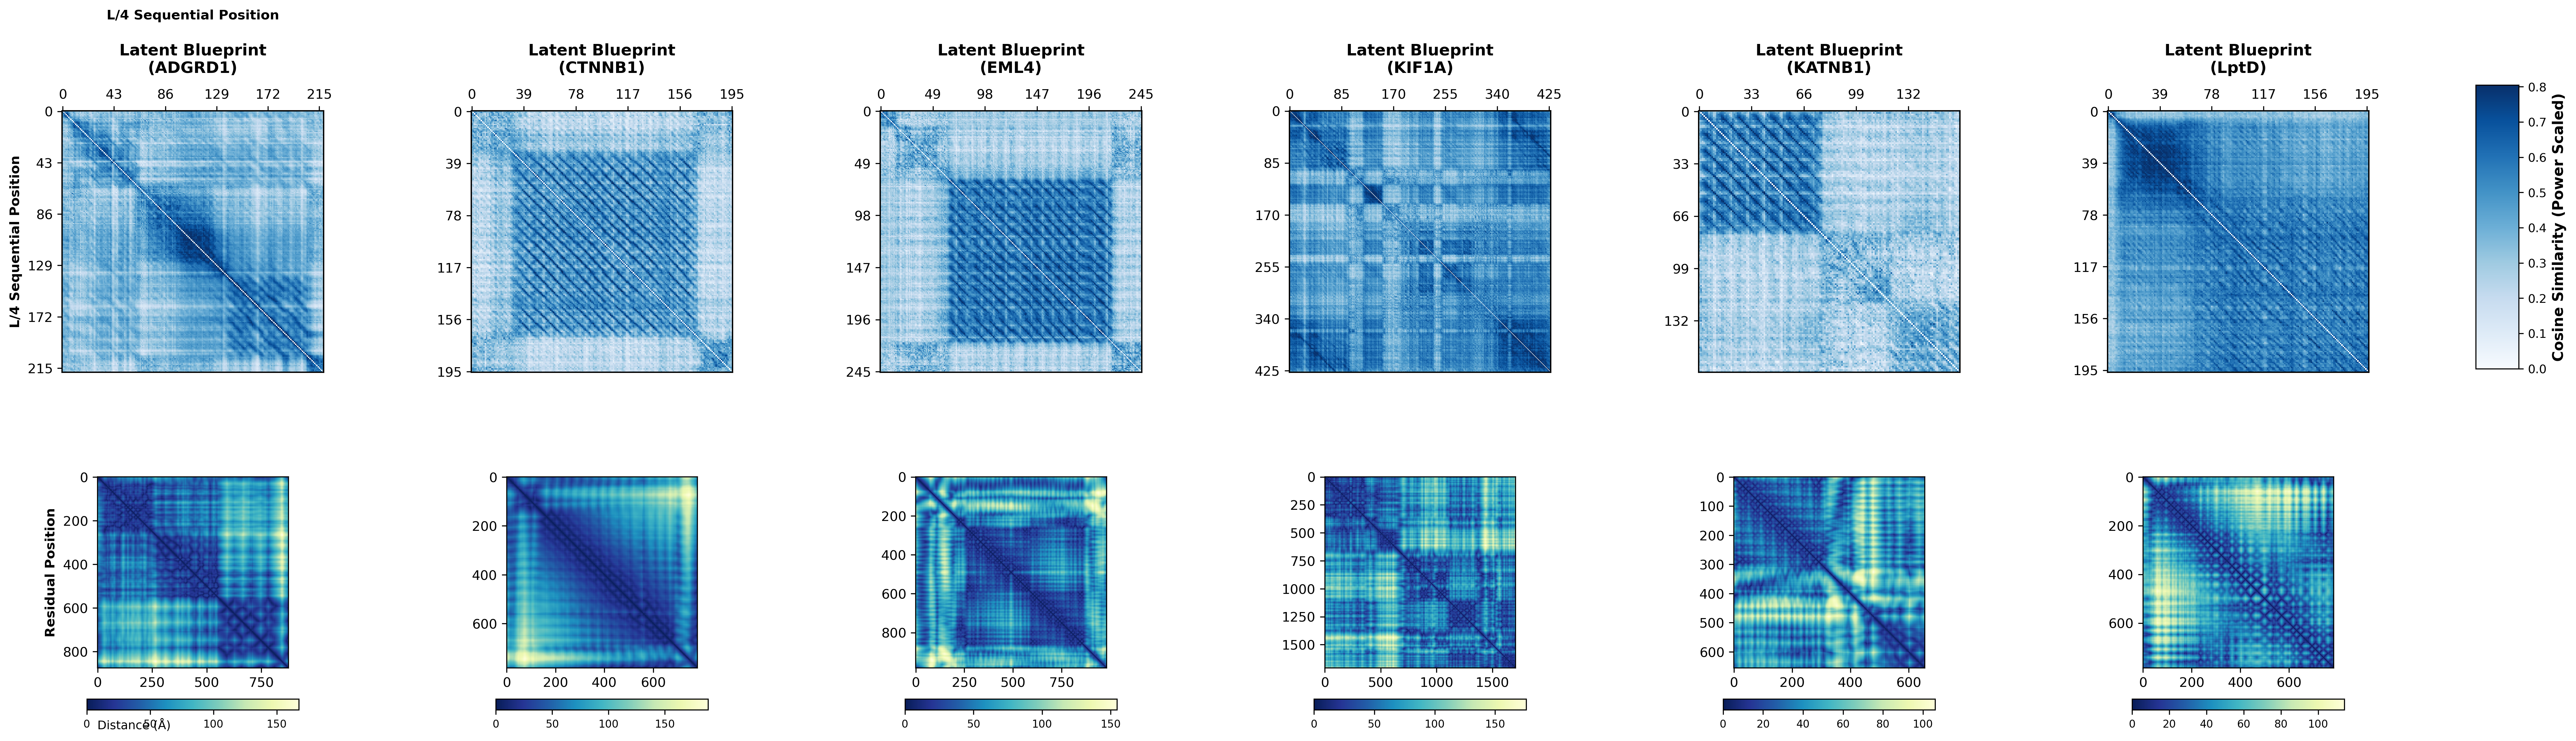

In [3]:
import os
import math
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from Bio.PDB import PDBParser, PPBuilder
device = torch.device("cpu" if torch.cuda.is_available() else "cpu")
protein_configs = [
    {"pdb_path": "../RELIC_data/figure3B/ADGRD1.pdb"},
    {"pdb_path": "../RELIC_data/figure3B/CTNNB1.pdb"},
    {"pdb_path": "../RELIC_data/figure3B/EML4.pdb"},
    {"pdb_path": "../RELIC_data/figure3B/KIF1A.pdb"},
    {"pdb_path": "../RELIC_data/figure3B/KATNB1.pdb"},
    {"pdb_path": "../RELIC_data/figure3B/LptD.pdb"},
]

num_proteins = len(protein_configs)
fig, axes = plt.subplots(nrows=2, ncols=num_proteins, figsize=(5 * num_proteins, 9), dpi=300)
if num_proteins == 1:
    axes = axes.reshape(2, 1)
parser = PDBParser(QUIET=True)
ppb = PPBuilder()
cmap_dist = 'YlGnBu_r'
blueprint_images = []
for col, config in enumerate(protein_configs):
    pdb_path = config["pdb_path"]
    name = os.path.splitext(os.path.basename(pdb_path))[0]
    print(f"Processing {name}...")
    try:
        structure = parser.get_structure(name, pdb_path)
        input_seq = ""
        for pp in ppb.build_peptides(structure):
            input_seq += str(pp.get_sequence())
        if not input_seq:
            print(f"Warning: Could not extract sequence from {name}. Skipping.")
            continue
        ca_atoms = [atom for atom in structure.get_atoms() if atom.name == 'CA']
        if not ca_atoms:
            print(f"Warning: No CA atoms found for {name}. Skipping.")
            continue
        token_ids = [alphabet.cls_idx] + list(alphabet.encode(input_seq)) + [alphabet.eos_idx]
        orig_len = len(token_ids)
        tokens = torch.tensor(token_ids, dtype=torch.long).unsqueeze(0).to(device)
        B, L = tokens.shape
        remainder = L % 4
        if remainder != 0:
            pad_amt = 4 - remainder
            tokens = F.pad(tokens, (0, pad_amt), value=alphabet.padding_idx)
        valid_l4 = math.ceil(orig_len / 4)
        features = {}
        def get_activation(act_name):
            def hook(module, input, output):
                if isinstance(output, tuple):
                    features[act_name] = output[0].detach().float()
                else:
                    features[act_name] = output.detach().float()
            return hook
        hook_handle = model.decoder_adapter.register_forward_hook(get_activation('Input_from_VQ'))
        with torch.no_grad():
            with torch.autocast(device_type="cuda" if "cuda" in str(device) else "cpu", dtype=torch.bfloat16):
                _ = model(tokens, vq_mix_ratio=1.0)
        hook_handle.remove()
        feat_tensor = features['Input_from_VQ']
        active_feats = feat_tensor[0, :, :valid_l4].permute(1, 0) 
        active_feats_norm = F.normalize(active_feats, p=2, dim=-1)
        sim_matrix = torch.matmul(active_feats_norm, active_feats_norm.T).cpu().numpy()
        sim_matrix_masked = sim_matrix.copy()
        np.fill_diagonal(sim_matrix_masked, np.nan)
        vmax = np.nanpercentile(sim_matrix_masked, 99.5)
        if np.isnan(vmax) or vmax <= 1e-5: 
            vmax = 1.0
        ax_bp = axes[0, col]
        cmap_bp = plt.get_cmap("Blues").copy()
        cmap_bp.set_bad(color='white')
        im_bp = ax_bp.imshow(sim_matrix_masked, cmap=cmap_bp, vmin=0.0, vmax=vmax, interpolation='nearest')
        blueprint_images.append(im_bp)
        step_bp = max(1, valid_l4 // 5)
        ticks_bp = np.arange(0, valid_l4, step_bp)
        ax_bp.set_xticks(ticks_bp)
        ax_bp.set_yticks(ticks_bp)
        ax_bp.xaxis.tick_top()
        ax_bp.xaxis.set_label_position('top')
        ax_bp.set_title(f"Latent Blueprint\n({name})", fontsize=12, fontweight='bold', pad=12)
        for spine in ax_bp.spines.values():
            spine.set_linewidth(1.0)
        if col == 0:
            ax_bp.set_ylabel("L/4 Sequential Position", fontsize=10, fontweight='bold')
            ax_bp.text(0.5, 1.35, "L/4 Sequential Position", transform=ax_bp.transAxes, 
                       fontsize=10, fontweight='bold', horizontalalignment='center')

        coords = np.array([atom.coord for atom in ca_atoms])
        diff = coords[:, np.newaxis, :] - coords[np.newaxis, :, :]
        dist_matrix = np.sqrt(np.sum(diff**2, axis=-1))
        ax_dist = axes[1, col]
        im_dist = ax_dist.imshow(dist_matrix, cmap=cmap_dist, origin='upper', interpolation='nearest')
        cbar_dist = fig.colorbar(im_dist, ax=ax_dist, orientation='horizontal', shrink=0.7, pad=0.12)
        cbar_dist.ax.tick_params(labelsize=8)
        if col == 0:
            ax_dist.set_ylabel("Residual Position", fontsize=10, fontweight='bold')
            ax_dist.text(0, -0.3, "Distance (Å)", transform=ax_dist.transAxes, fontsize=9, verticalalignment='center')
    except Exception as e:
        print(f"Error processing {name} from {pdb_path}: {e}")

if blueprint_images:
    cbar_ax_bp = fig.add_axes([0.93, 0.55, 0.015, 0.33]) # [left, bottom, width, height]
    cbar_bp = fig.colorbar(blueprint_images[-1], cax=cbar_ax_bp)
    cbar_bp.set_label('Cosine Similarity (Power Scaled)', size=11, fontweight='bold')
    cbar_bp.ax.tick_params(labelsize=9)

plt.subplots_adjust(left=0.08, right=0.90, top=0.85, bottom=0.12, wspace=0.35, hspace=0.4)
plt.show()

## Figure 3C


Processing Sequence 1/4: TPI1
[TPI1] Input Length: 249 | Tokens: 251 -> Padded to: 252
✅ FASTA file saved for TPI1 to: MultiSeq_TPI1.fasta

Processing Sequence 2/4: OSM-3 kinesin motor
[OSM-3 kinesin motor] Input Length: 360 | Tokens: 362 -> Padded to: 364
✅ FASTA file saved for OSM-3 kinesin motor to: MultiSeq_OSM-3 kinesin motor.fasta

Processing Sequence 3/4: KRAS
[KRAS] Input Length: 189 | Tokens: 191 -> Padded to: 192
✅ FASTA file saved for KRAS to: MultiSeq_KRAS.fasta

Processing Sequence 4/4: CDK2
[CDK2] Input Length: 298 | Tokens: 300 (Already divisible by 4)
✅ FASTA file saved for CDK2 to: MultiSeq_CDK2.fasta


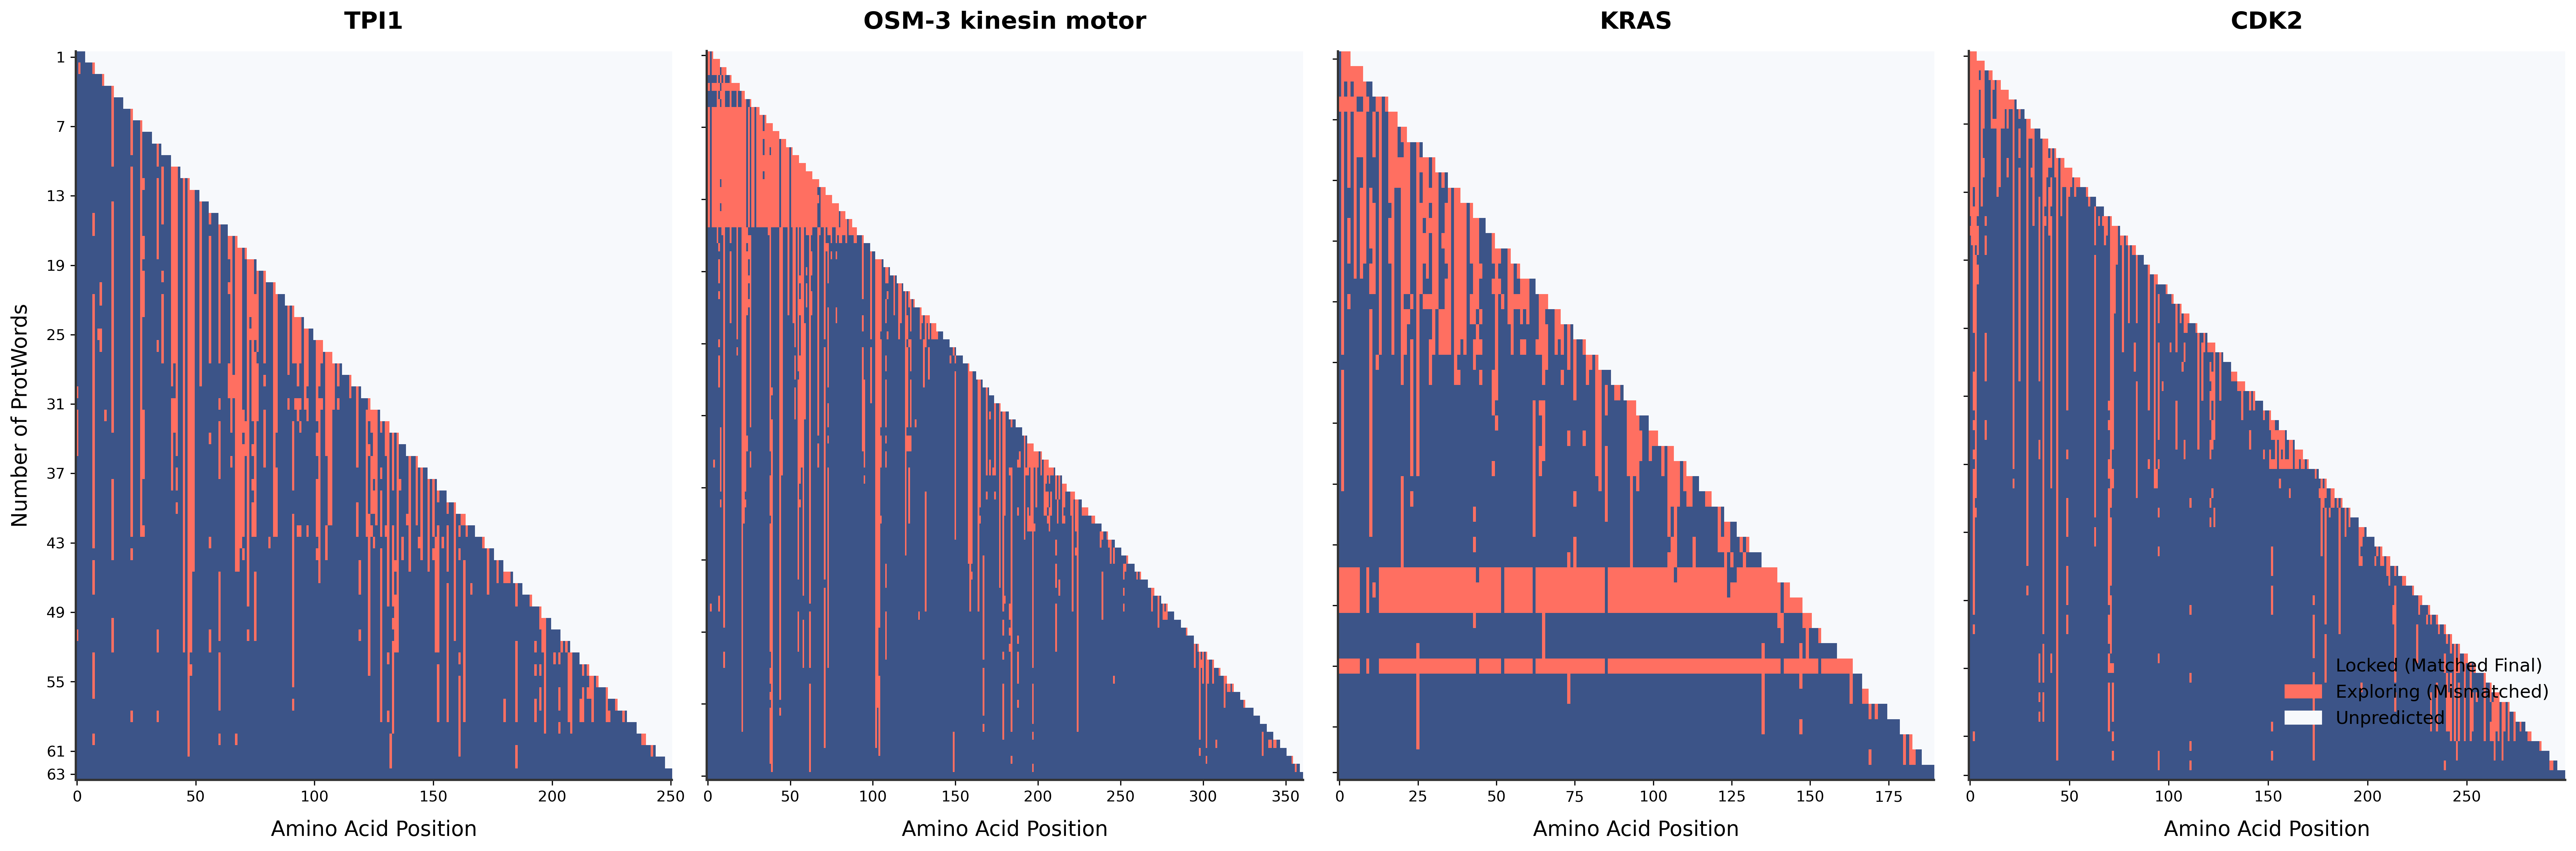

In [4]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

def test_multiple_reconstructions_and_visualize(model, alphabet, sequences_dict, device='cpu', output_prefix='incremental_decoding'):
    model.eval()
    model.to(device)
    
    num_seqs = len(sequences_dict)
    fig, axes = plt.subplots(nrows=1, ncols=num_seqs, figsize=(6 * num_seqs, 8), dpi=300)

    if num_seqs == 1:
        axes = [axes]

    cmap = ListedColormap(['#F7F9FC', '#FF6F61', '#3C5488'])

    for idx, (name, input_seq) in enumerate(sequences_dict.items()):
        print(f"\n" + "="*80)
        print(f"Processing Sequence {idx+1}/{num_seqs}: {name}")
        print("="*80)
        
        token_ids = [alphabet.cls_idx] + list(alphabet.encode(input_seq)) + [alphabet.eos_idx]
        tokens = torch.tensor(token_ids, dtype=torch.long).unsqueeze(0).to(device)
        
        B, L = tokens.shape
        remainder = L % 4
        if remainder != 0:
            pad_amt = 4 - remainder
            tokens = F.pad(tokens, (0, pad_amt), value=alphabet.padding_idx)
            print(f"[{name}] Input Length: {len(input_seq)} | Tokens: {L} -> Padded to: {tokens.shape[1]}")
        else:
            print(f"[{name}] Input Length: {len(input_seq)} | Tokens: {L} (Already divisible by 4)")

        with torch.no_grad():
            with torch.autocast(device_type="cuda" if "cuda" in str(device) else "cpu", dtype=torch.bfloat16):
                _, _, _, indices = model(tokens, vq_mix_ratio=1.0)
        
        indices = indices.view(1, -1)
        L_4 = indices.shape[1]
        
        vq_module = getattr(model, "module", model).vq
        embed_weights = vq_module.layers[0].embedding.weight

        special_tokens = {
            alphabet.cls_idx, alphabet.padding_idx, alphabet.eos_idx, 
            alphabet.unk_idx, alphabet.mask_idx
        }

        steps = list(range(1, L_4 + 1))
        decoded_dict = {} 

        for k in steps:
            trunc_indices = indices[:, :k] 
            
            with torch.no_grad():
                with torch.autocast(device_type="cuda" if "cuda" in str(device) else "cpu", dtype=torch.bfloat16):
                    z_q = embed_weights[trunc_indices] # [1, k, C]
                    z_q = z_q.permute(0, 2, 1)         # [1, C, k]
                    
                    restored = model.decoder_adapter(z_q)
                    mask_l4 = torch.zeros((1, k), dtype=torch.bool, device=device)
                    mask_l2 = torch.zeros((1, k * 2), dtype=torch.bool, device=device)
                    logits = model.decoder(restored, mask_l4, mask_l2)
                    
            pred_ids = logits.argmax(dim=-1).squeeze(0).cpu().numpy()
            seq_chars = [alphabet.get_tok(p_id) for p_id in pred_ids if p_id not in special_tokens]
            decoded_str = "".join(seq_chars)
            decoded_dict[k] = decoded_str

        fasta_path = f"{output_prefix}_{name}.fasta"
        with open(fasta_path, "w") as f:
            for k in steps:
                f.write(f">ProtWords_0_to_{k}\n{decoded_dict[k]}\n")
        print(f"✅ FASTA file saved for {name} to: {fasta_path}")

        final_seq = decoded_dict[steps[-1]]
        max_len = max(len(seq) for seq in decoded_dict.values())
        matrix = np.zeros((len(steps), max_len))

        for i, k in enumerate(steps):
            seq = decoded_dict[k]
            for j in range(max_len):
                if j >= len(seq):
                    matrix[i, j] = 0
                else:
                    if j < len(final_seq) and seq[j] == final_seq[j]:
                        matrix[i, j] = 2
                    else:
                        matrix[i, j] = 1

        ax = axes[idx]
        ax.imshow(matrix, cmap=cmap, aspect='auto')
        ax.set_title(name, fontsize=16, fontweight='bold', pad=15)

        y_ticks = np.arange(0, len(steps), max(1, len(steps)//10))
        y_ticklabels = [steps[i] for i in y_ticks]
        if (len(steps)-1) not in y_ticks:
            y_ticks = np.append(y_ticks, len(steps)-1)
            y_ticklabels.append(steps[-1])
            
        ax.set_yticks(y_ticks)
        ax.set_yticklabels(y_ticklabels, fontsize=10)
        ax.set_xlabel("Amino Acid Position", fontsize=14, labelpad=10)

        if idx == 0:
            ax.set_ylabel("Number of ProtWords", fontsize=14, labelpad=10)
        else:
            ax.set_yticklabels([])

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_edgecolor('#333333')
        ax.spines['left'].set_linewidth(1.5)
        ax.spines['bottom'].set_edgecolor('#333333')
        ax.spines['bottom'].set_linewidth(1.5)

        if idx == num_seqs - 1:
            legend_elements = [
                mpatches.Patch(color='#3C5488', label='Locked (Matched Final)'),
                mpatches.Patch(color='#FF6F61', label='Exploring (Mismatched)'),
                mpatches.Patch(color='#F7F9FC', label='Unpredicted')
            ]
            ax.legend(handles=legend_elements, loc='lower right', frameon=False, fontsize=12, bbox_to_anchor=(1.0, 0.05))

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    DEVICE = "cpu" if torch.cuda.is_available() else "cpu"
    test_sequences = {
        "TPI1": "MAPSRKFFVGGNWKMNGRKQSLGELIGTLNAAKVPADTEVVCAPPTAYIDFARQKLDPKIAVAAQNCYKVTNGAFTGEISPGMIKDCGATWVVLGHSERRHVFGESDELIGQKVAHALAEGLGVIACIGEKLDEREAGITEKVVFEQTKVIADNVKDWSKVVLAYEPVWAIGTGKTATPQQAQEVHEKLRGWLKSNVSDAVAQSTRIIYGGSVTGATCKELASQPDVDGFLVGGASLKPEFVDIINAKQ",
        "OSM-3 kinesin motor":"MAESVRVAVRCRPFNQREKDLNTTLCVGMTPNVGQVNLNAPDGAAKDFTFDGAYFMDSTGEQIYNDIVFPLVENVIEGYNGTVFAYGQTGSGKTFSMQGIETIPAQRGVIPRAFDHIFTATATTENVKFLVHCSYLEIYNEEVRDLLGADNKQKLEIKEQPDRGVYVAGLSMHVCHDVPACKELMTRGFNNRHVGATLMNKDSSRSHSIFTVYVEGMTETGSIRMGKLNLVDLAGSERQSKTGATGDRLKEATKINLSLSALGNVISALVDGKSKHIPYRDSKLTRLLQDSLGGNTKTIMIACVSPSSDNYDETLSTLRYANRAKNIKNKPTINEDPKDALLREYQEEIARLKSMVQPGA",
        "KRAS": "MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVIDGETCLLDILDTAGQEEYSAMRDQYMRTGEGFLCVFAINNTKSFEDIHHYREQIKRVKDSEDVPMVLVGNKCDLPSRTVDTKQAQDLARSYGIPFIETSAKTRQRVEDAFYTLVREIRQYRLKKISKEEKTPGCVKIKKCIIM",
        "CDK2": "MENFQKVEKIGEGTYGVVYKARNKLTGEVVALKKIRLDTETEGVPSTAIREISLLKELNHPNIVKLLDVIHTENKLYLVFEFLHQDLKKFMDASALTGIPLPLIKSYLFQLLQGLAFCHSHRVLHRDLKPQNLLINTEGAIKLADFGLARAFGVPVRTYTHEVVTLWYRAPEILLGCKYYSTAVDIWSLGCIFAEMVTRRALFPGDSEIDQLFRIFRTLGTPDEVVWPGVTSMPDYKPSFPKWARQDFSKVVPPLDEDGRSLLSQMLHYDPNKRISAKAALAHPFFQDVTKPVPHLRL",
    }
    test_multiple_reconstructions_and_visualize(model, alphabet, test_sequences, device=DEVICE, output_prefix='MultiSeq')